In [53]:
import networkx as nx
import numpy as np
import random
rng = np.random.default_rng(42)
from matplotlib import pyplot as plt
from collections import defaultdict
from tqdm import tqdm

In [47]:

N = 1000
communities = 10
sizes = [N // communities] * communities
p_in, p_out = 0.06, 0.002  # denser within communities

In [48]:
# 1) Base SBM (undirected template)
probs = np.full((communities, communities), p_out)
np.fill_diagonal(probs, p_in)
G_base = nx.stochastic_block_model(sizes, probs, seed=42, directed=False)

In [49]:
sizes

[100, 100, 100, 100, 100, 100, 100, 100, 100, 100]

In [50]:
# 2) Make it directed and initialize trust weights
G = nx.DiGraph()
G.add_nodes_from(G_base.nodes(data=True))
alpha0, beta0 = 2.0, 5.0  # Beta prior skewed low
for u, v in G_base.edges():
    if rng.random() < 0.7:
        G.add_edge(u, v, w=float(rng.beta(alpha0, beta0)))
    if rng.random() < 0.7:
        G.add_edge(v, u, w=float(rng.beta(alpha0, beta0)))


In [51]:
# Node attributes (homophily features)
for node in G.nodes():
    # community is already in 'block' field from SBM
    G.nodes[node]['interest'] = rng.integers(0, 10)   # 10 topical interests
    G.nodes[node]['seniority'] = rng.normal(0, 1)     # continuous trait


In [52]:
def homophily(u, v, lam=0.8):
    iu = G.nodes[u]['interest']; iv = G.nodes[v]['interest']
    su = G.nodes[u]['seniority']; sv = G.nodes[v]['seniority']
    d = abs(iu - iv) + 0.5 * abs(su - sv)
    return np.exp(-lam * d)

def pref_attach(v, eps=1.0, alpha=0.7):
    return (G.in_degree(v) + eps) ** alpha

def reciprocity(u, v, rho=0.5):
    return rho if G.has_edge(v, u) else 0.0

def triadic_closure(u, v, theta=1.0):
    # max 2-hop trust via any k
    best = 0.0
    for k in G.successors(u):
        if G.has_edge(k, v):
            best = max(best, G[u][k]['w'] * G[k][v]['w'])
    return theta * best

def capacity_factor(u, dstar=80, kappa=0.08):
    return 1.0 / (1.0 + np.exp(kappa * (G.out_degree(u) - dstar)))

def form_prob(u, v, a=0.4, b=0.3, c=0.2, r=0.1):
    score = (a * homophily(u, v) +
             b * pref_attach(v) +
             c * triadic_closure(u, v) +
             r * reciprocity(u, v))
    return np.tanh(score) * capacity_factor(u)  # squashing + capacity

def reinforce(w, eta_pos=0.25):  # positive interaction
    return w + eta_pos * (1.0 - w)

def penalize(w, eta_neg=0.5):    # negative interaction
    return w - eta_neg * w

def decay(w, gamma=0.01):
    return w * np.exp(-gamma)


In [54]:
T = 50
tau = 0.05     # sparsity threshold
beta_prop = 0.4  # bounded propagation factor
p_interact = 0.05

for t in tqdm(range(T)):
    # Candidate sampling: mix random, homophily, pref-attach
    candidates = []
    nodes = list(G.nodes())
    for _ in range(N // 2):
        u = int(rng.integers(0, N))
        # sample v biased by homophily + pref attach
        weights = []
        for v in nodes:
            if v == u: 
                weights.append(0.0)
            else:
                weights.append(0.6 * homophily(u, v) + 0.4 * pref_attach(v))
        v = int(rng.choice(nodes, p=np.array(weights)/np.sum(weights)))
        candidates.append((u, v))

    # Attempt formations or reinforcements
    for u, v in candidates:
        if not G.has_edge(u, v):
            p = form_prob(u, v)
            if rng.random() < min(1.0, p):
                G.add_edge(u, v, w=float(rng.beta(2, 8)))
        else:
            # Simulate an interaction outcome
            if rng.random() < p_interact:
                success = rng.random() < 0.8  # base accuracy 80%
                w = G[u][v]['w']
                w = reinforce(w) if success else penalize(w)
                G[u][v]['w'] = float(np.clip(w, 0.0, 1.0))

    # Decay + prune small weights
    for u, v, data in list(G.edges(data=True)):
        G[u][v]['w'] = float(decay(data['w']))
        if G[u][v]['w'] < tau:
            G.remove_edge(u, v)

    # Bounded trust propagation (2-hop, sparse) — batched to avoid dict mutation
    to_set = []
    to_add = []
    
    for u in nodes:
        succ_u = list(G.successors(u))  # snapshot neighbor list
        for k in succ_u:
            wk = G[u][k]['w']
            if wk < 0.2:
                continue
            succ_k = list(G.successors(k))  # snapshot neighbor list
            for v in succ_k:
                if u == v:
                    continue  # optional: skip self-loops
                wkv = G[k][v]['w']
                propagated = beta_prop * wk * wkv
                if propagated <= tau:
                    continue
    
                if G.has_edge(u, v):
                    if propagated > G[u][v]['w']:
                        to_set.append((u, v, float(propagated)))
                else:
                    if rng.random() < capacity_factor(u):
                        to_add.append((u, v, float(propagated)))
    
    # Apply updates AFTER traversal
    for u, v, w in to_set:
        if w > G[u][v]['w']:
            G[u][v]['w'] = w
    
    for u, v, w in to_add:
        if G.has_edge(u, v):
            if w > G[u][v]['w']:
                G[u][v]['w'] = w
        else:
            G.add_edge(u, v, w=w)



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:05<00:00,  2.50s/it]


In [55]:
# Example diagnostics
avg_deg = np.mean([G.out_degree(n) for n in G.nodes()])
reciprocity_ratio = nx.reciprocity(G)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Average out-degree:", round(avg_deg, 2))
print("Reciprocity:", round(reciprocity_ratio or 0.0, 3))

Nodes: 1000 Edges: 36853
Average out-degree: 36.85
Reciprocity: 0.12


{(0, 6): '0.10', (0, 7): '0.17', (0, 9): '0.29', (0, 10): '0.34', (0, 5): '0.15', (0, 2): '0.18', (0, 3): '0.07', (0, 4): '0.20', (0, 11): '0.10', (1, 3): '0.16', (1, 6): '0.12', (1, 9): '0.08', (1, 8): '0.22', (1, 7): '0.16', (1, 11): '0.07', (1, 10): '0.10', (1, 5): '0.22', (1, 0): '0.07', (1, 4): '0.31', (2, 0): '0.22', (2, 9): '0.08', (2, 8): '0.13', (2, 7): '0.24', (2, 6): '0.26', (3, 1): '0.08', (3, 6): '0.08', (3, 11): '0.25', (3, 0): '0.13', (3, 7): '0.30', (3, 10): '0.08', (3, 4): '0.12', (3, 9): '0.29', (3, 2): '0.14', (3, 5): '0.22', (4, 5): '0.07', (4, 8): '0.15', (4, 7): '0.11', (4, 9): '0.13', (4, 2): '0.21', (4, 11): '0.51', (4, 6): '0.07', (5, 6): '0.13', (5, 8): '0.26', (5, 7): '0.07', (5, 0): '0.21', (5, 4): '0.13', (5, 3): '0.18', (6, 5): '0.09', (6, 7): '0.07', (6, 8): '0.14', (6, 9): '0.07', (6, 10): '0.09', (6, 2): '0.06', (6, 3): '0.22', (7, 8): '0.14', (7, 6): '0.11', (7, 9): '0.12', (7, 3): '0.07', (7, 0): '0.12', (7, 5): '0.25', (7, 2): '0.28', (7, 4): '0.25',

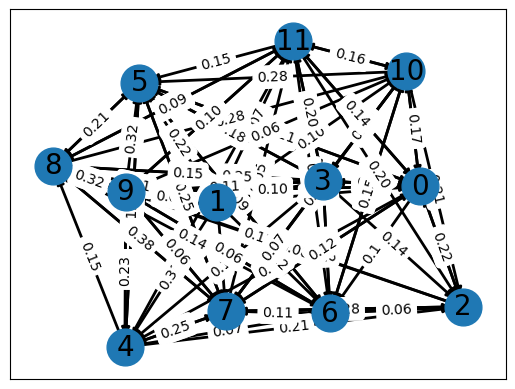

In [37]:
pos = nx.spring_layout(G, seed=23)  # positions for all nodes - seed for reproducibility
nx.draw_networkx_nodes(G, pos, node_size=700),
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=2),
nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
edge_labels = nx.get_edge_attributes(G, "w")
#print(edge_labels)
format_labels = {k:"%.2f"%v for k,v in edge_labels.items()}
print(format_labels)
nx.draw_networkx_edge_labels(G, pos, format_labels)
plt.show()

In [56]:
def run_simulation(G, packets_per_node=50, rounds=10):
    packets_in = {}
    packets_out = defaultdict(int)
    for n in G.nodes:
        packets_in[n] = packets_per_node
    #print(packets_in)
    for epoch in range(rounds):
        for n in G.nodes:
            #print(n)
            neighbours = list(G.successors(n))
            #print(neighbours)
            weights = [G.edges[(n,neigh)]["w"] for neigh in neighbours]
            #print(weights)
            for inp in range(packets_in[n]):
                next_hop = random.choices(neighbours, weights=weights, k=1)[0]
                packets_out[next_hop] += 1
        #print(packets_out)
        packets_in = packets_out
        packets_out = defaultdict(int)
        #break
    return packets_in

In [57]:
final_pkt = run_simulation(G)

In [58]:
ranked = nx.pagerank(G, weight='w', alpha=1.0)

In [62]:
diffs = []
for n,p in final_pkt.items():
    walk = p/sum(final_pkt.values())
    print(n, walk, ranked[n], walk/ranked[n])
    diffs.append((walk-ranked[n], walk/ranked[n], walk, ranked[n]))

834 0.00102 0.0009541830072274771 1.068977326439468
356 0.00118 0.0012474559460636566 0.9459251877579216
202 0.00146 0.0013316887617895925 1.0963522723117196
827 0.00122 0.001129424201173316 1.0801964387982728
810 0.00098 0.0011950113869023129 0.8200758676788331
147 0.00136 0.001573834615292822 0.8641314575146534
52 0.00174 0.001818049917273769 0.957069431079864
805 0.00186 0.0015472929977346538 1.2020994102107172
415 0.00094 0.0007513868697494544 1.251019997612465
68 0.00074 0.0007806295537576397 0.9479528368327009
209 0.00116 0.0011864187402527428 0.977732364336124
263 0.00104 0.0009054446166603943 1.148606972600814
289 0.00046 0.0002939319494312276 1.5649880895565182
13 0.00278 0.0024584098420895205 1.1308122642549887
458 0.00156 0.0016485886929923912 0.9462639205467364
555 0.00066 0.0006830625284277417 0.9662365779589366
629 0.00116 0.0013489688243526804 0.8599160922467134
935 0.002 0.0017090325228646282 1.1702527443115365
431 0.00106 0.0012011079366825844 0.8825185211311488
34 0.0

In [63]:
list(sorted(diffs))

[(-0.00044958986982248663, 0.7693925903177664, 0.0015, 0.0019495898698224867),
 (-0.00035336734195345757, 0.7180656220045508, 0.0009, 0.0012533673419534575),
 (-0.0003375556177475287, 0.8405918527388712, 0.00178, 0.0021175556177475286),
 (-0.00033679051894952886, 0.6813081562424449, 0.00072, 0.001056790518949529),
 (-0.00032915637742013523, 0.7560280016986985, 0.00102, 0.0013491563774201353),
 (-0.0003158821596409971, 0.7358584563751459, 0.00088, 0.0011958821596409971),
 (-0.0003157820365643541, 0.7635976320084757, 0.00102, 0.0013357820365643542),
 (-0.00031511217082266926, 0.7318450283754049, 0.00086, 0.0011751121708226692),
 (-0.00031323074997032787, 0.8058363628538018, 0.0013, 0.0016132307499703278),
 (-0.0003123319052514388, 0.7465521229139059, 0.00092, 0.0012323319052514388),
 (-0.00031153633921841666, 0.7792927248398595, 0.0011, 0.0014115363392184167),
 (-0.000311506742702675, 0.7883076348460767, 0.00116, 0.001471506742702675),
 (-0.0003106933293980606, 0.8339154127961564, 0.0015

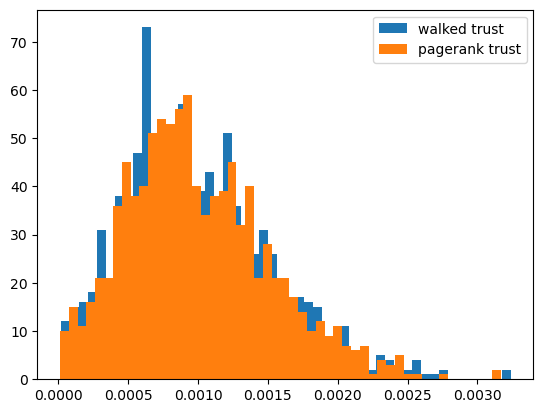

In [67]:
plt.hist([d[2] for d in diffs], bins=50, label="walked trust")
plt.hist([d[3] for d in diffs], bins=50, label="pagerank trust")
plt.legend()

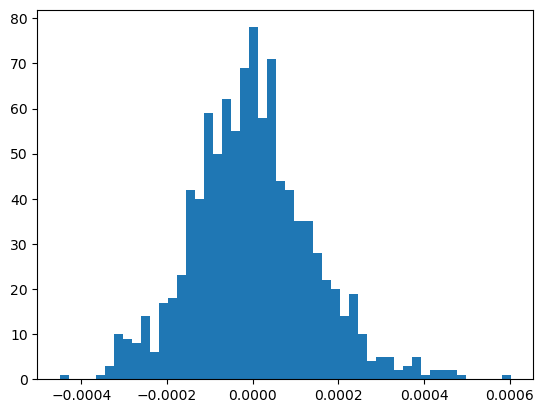

In [69]:
plt.hist([d[0] for d in diffs], bins=50, label="absolute diffs")
plt.show()

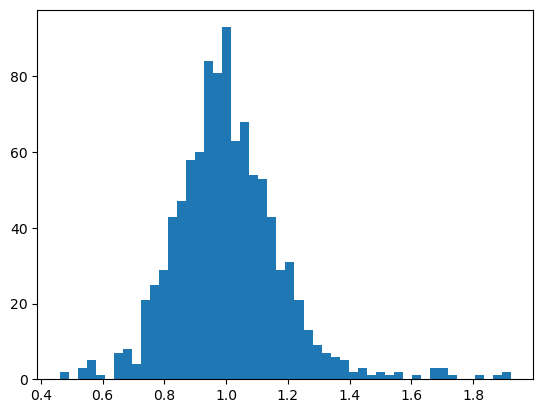

In [70]:
plt.hist([d[1] for d in diffs], bins=50, label="relative diffs")
plt.show()

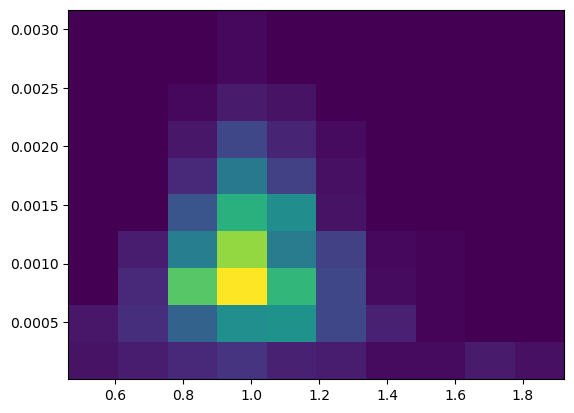

In [75]:
plt.hist2d([d[1] for d in diffs],[d[3] for d in diffs])
plt.show()